<a href="https://colab.research.google.com/github/marifinilham-ds/east-java-positive-deviance-few/blob/main/notebooks/02_model_residual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd, numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# --- 3.1: baca dan gabung data dari GitHub ---
base = ('https://raw.githubusercontent.com/marifinilham-ds/'
        'east-java-positive-deviance-few/main/data/raw/')
padi = pd.read_csv(base + 'bps/padi_jatim_2019_2022.csv')
clim = pd.read_csv(base + 'satellite/iklim_ndvi_jatim_2019_2022.csv')
sat  = pd.read_csv(base + 'satellite/viirs_cropndvi_jatim_2019_2022.csv')

key = ['kabupaten_kota', 'jenis', 'tahun']
df = padi.merge(clim, on=key).merge(sat, on=key)
assert len(df) == 152
df = df.rename(columns={'produktivitas_hitung_kuha': 'y'})
print(df.shape)

feats = ['rain_annual_mm', 'rain_dry_mm', 'ndvi_mean', 'ndvi_max',
         'ndvi_crop_mean', 'ndvi_crop_max', 'crop_share', 'ntl_mean']
z = df.copy()
z['ntl_mean'] = np.log1p(z['ntl_mean'])
for c in ['y'] + feats:
    z[c] = z.groupby('tahun')[c].transform(lambda s: (s - s.mean()) / s.std())

# --- 3.2: model dan residual (29 kabupaten) ---
k = z[z.jenis == 'kabupaten'].reset_index(drop=True)
X, y, g = k[feats], k['y'], k['kabupaten_kota']

models = {
    'ridge': make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    'rf': RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42),
}
for name, m in models.items():
    k['pred_' + name] = cross_val_predict(m, X, y, cv=LeaveOneGroupOut(), groups=g)
    k['res_' + name] = y - k['pred_' + name]
    print(name, 'R2 leave-one-regency-out =', round(r2_score(y, k['pred_' + name]), 3))

res = k.groupby('kabupaten_kota')[['res_ridge', 'res_rf']].mean().round(2)
print('\nResidual tertinggi (kandidat positive deviant):')
print(res.sort_values('res_rf', ascending=False).head(8))
print('\nResidual terendah:')
print(res.sort_values('res_rf').head(5))

(152, 16)
ridge R2 leave-one-regency-out = 0.037
rf R2 leave-one-regency-out = 0.381

Residual tertinggi (kandidat positive deviant):
                res_ridge  res_rf
kabupaten_kota                   
Tulungagung          0.67    1.27
Blitar               1.49    1.10
Ponorogo             0.50    0.93
Sidoarjo             1.27    0.88
Trenggalek           0.38    0.73
Jombang              0.64    0.65
Gresik               0.51    0.47
Nganjuk              0.38    0.36

Residual terendah:
                res_ridge  res_rf
kabupaten_kota                   
Pacitan             -1.77   -1.40
Bojonegoro          -1.10   -1.12
Sumenep              0.73   -0.94
Mojokerto           -0.34   -0.75
Jember              -1.06   -0.69


In [14]:
# 1. Konsistensi per tahun (RF)
piv = k.pivot_table(index='kabupaten_kota', columns='tahun', values='res_rf')
summ = pd.DataFrame({
    'rata2': piv.mean(axis=1),
    'tahun_positif': (piv > 0).sum(axis=1),
    'terendah': piv.min(axis=1),
}).round(2)
print(piv.round(2).loc[summ.sort_values('rata2', ascending=False).head(10).index])
print(summ.sort_values('rata2', ascending=False).head(10))

# 2. Tanpa 2022 (data sementara BPS)
k2 = k[k.tahun != 2022].reset_index(drop=True)
pred2 = cross_val_predict(models['rf'], k2[feats], k2['y'],
                          cv=LeaveOneGroupOut(), groups=k2['kabupaten_kota'])
k2['res'] = k2['y'] - pred2
print('\nR2 tanpa 2022:', round(r2_score(k2['y'], pred2), 3))
print(k2.groupby('kabupaten_kota')['res'].mean().round(2)
        .sort_values(ascending=False).head(8))

# 3. Fitur apa yang dipakai RF (kasar, model dilatih pada semua data)
rf_all = models['rf'].fit(X, y)
print('\nPentingnya fitur (kasar):')
print(pd.Series(rf_all.feature_importances_, index=feats).sort_values(ascending=False).round(3))

tahun           2019  2020  2021  2022
kabupaten_kota                        
Tulungagung     1.15  1.62  1.65  0.65
Blitar          1.10  0.28  1.54  1.46
Ponorogo        0.77  0.84  1.25  0.86
Sidoarjo        1.49  0.86  0.49  0.65
Trenggalek      1.11  0.88  0.47  0.48
Jombang         0.65  0.61  0.41  0.93
Gresik          0.02  0.20  0.52  1.16
Nganjuk         0.64  0.50  0.64 -0.33
Magetan         0.03  0.68  0.51  0.21
Pasuruan        0.28  0.16  0.46  0.45
                rata2  tahun_positif  terendah
kabupaten_kota                                
Tulungagung      1.27              4      0.65
Blitar           1.10              4      0.28
Ponorogo         0.93              4      0.77
Sidoarjo         0.88              4      0.49
Trenggalek       0.73              4      0.47
Jombang          0.65              4      0.41
Gresik           0.47              4      0.02
Nganjuk          0.36              3     -0.33
Magetan          0.35              4      0.03
Pasuruan       

In [15]:
def loro(cols):
    m = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42)
    p = cross_val_predict(m, k[cols], k['y'], cv=LeaveOneGroupOut(),
                          groups=k['kabupaten_kota'])
    r = (k['y'] - p).groupby(k['kabupaten_kota']).mean()
    return r2_score(k['y'], p), r

variants = {
    'semua': feats,
    'tanpa_crop_share': [f for f in feats if f != 'crop_share'],
    'tanpa_ntl': [f for f in feats if f != 'ntl_mean'],
    'tanpa_keduanya': [f for f in feats if f not in ('crop_share', 'ntl_mean')],
}
cands = ['Tulungagung', 'Blitar', 'Ponorogo', 'Sidoarjo', 'Trenggalek', 'Jombang']
tab, r2s = {}, {}
for name, cols in variants.items():
    r2s[name], tab[name] = loro(cols)
print({n: round(v, 3) for n, v in r2s.items()})
print(pd.DataFrame(tab).loc[cands].round(2))

{'semua': 0.381, 'tanpa_crop_share': 0.015, 'tanpa_ntl': 0.355, 'tanpa_keduanya': 0.088}
                semua  tanpa_crop_share  tanpa_ntl  tanpa_keduanya
kabupaten_kota                                                    
Tulungagung      1.27              0.23       1.16            0.33
Blitar           1.10              0.68       0.94            0.74
Ponorogo         0.93              0.02       0.96           -0.46
Sidoarjo         0.88              0.86       0.84            0.83
Trenggalek       0.73              0.79       0.22            0.64
Jombang          0.65              1.42       0.67            1.33


In [16]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import r2_score

base = ('https://raw.githubusercontent.com/marifinilham-ds/'
        'east-java-positive-deviance-few/main/data/raw/')
padi = pd.read_csv(base + 'bps/padi_jatim_2019_2022.csv')
clim = pd.read_csv(base + 'satellite/iklim_ndvi_jatim_2019_2022.csv')
sat  = pd.read_csv(base + 'satellite/viirs_cropndvi_jatim_2019_2022.csv')
irg  = pd.read_csv(base + 'bps/sawah_pengairan_jatim_2017.csv')

key = ['kabupaten_kota', 'jenis', 'tahun']
df = (padi.merge(clim, on=key).merge(sat, on=key)
      .merge(irg[['kabupaten_kota', 'jenis', 'irig_share']], on=['kabupaten_kota', 'jenis'])
      .rename(columns={'produktivitas_hitung_kuha': 'y'}))
assert len(df) == 152 and df.isna().sum().sum() == 0

feats = ['rain_annual_mm', 'rain_dry_mm', 'ndvi_mean', 'ndvi_max',
         'ndvi_crop_mean', 'ndvi_crop_max', 'crop_share', 'ntl_mean', 'irig_share']
z = df.copy(); z['ntl_mean'] = np.log1p(z['ntl_mean'])
for c in ['y'] + feats:
    z[c] = z.groupby('tahun')[c].transform(lambda s: (s - s.mean()) / s.std())

kab = z[z.jenis == 'kabupaten'].reset_index(drop=True)
kota = z[z.jenis == 'kota'].reset_index(drop=True)
variants = {'semua': feats,
            'tanpa_crop': [f for f in feats if f != 'crop_share'],
            'tanpa_ntl': [f for f in feats if f != 'ntl_mean']}
mk = lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42)

def resid(d, cols):
    p = cross_val_predict(mk(), d[cols], d['y'], cv=LeaveOneGroupOut(), groups=d['kabupaten_kota'])
    return (d['y'] - p).groupby(d['kabupaten_kota']).mean(), r2_score(d['y'], p)

cands = ['Gresik', 'Blitar', 'Sidoarjo', 'Jombang', 'Tulungagung', 'Ponorogo', 'Trenggalek']
full, no22, r2 = {}, {}, {}
for n, cols in variants.items():
    full[n], r2[n] = resid(kab, cols)
    no22[n], _ = resid(kab[kab.tahun != 2022].reset_index(drop=True), cols)
print('R2 (semua tahun):', {n: round(v, 3) for n, v in r2.items()})
print('\nResidual rata-rata, semua tahun:')
print(pd.DataFrame(full).loc[cands].round(2))
print('\nResidual rata-rata, TANPA 2022:')
print(pd.DataFrame(no22).loc[cands].round(2))

m = mk().fit(kab[variants['semua']], kab['y'])
kota['res'] = kota['y'] - m.predict(kota[variants['semua']])
print('\nResidual kota (model dilatih di kabupaten):')
print(kota.groupby('kabupaten_kota')['res'].mean().round(2).sort_values(ascending=False))

R2 (semua tahun): {'semua': 0.39, 'tanpa_crop': -0.025, 'tanpa_ntl': 0.308}

Residual rata-rata, semua tahun:
                semua  tanpa_crop  tanpa_ntl
kabupaten_kota                              
Gresik           1.23        1.95       1.23
Blitar           1.01        0.66       0.99
Sidoarjo         0.88        1.07       0.84
Jombang          0.60        0.79       0.59
Tulungagung      1.15        0.17       1.06
Ponorogo         0.96        0.10       0.97
Trenggalek      -0.27        0.60      -0.58

Residual rata-rata, TANPA 2022:
                semua  tanpa_crop  tanpa_ntl
kabupaten_kota                              
Gresik           0.84        1.68       0.86
Blitar           0.92        0.51       0.88
Sidoarjo         1.07        1.22       1.09
Jombang          0.59        0.70       0.59
Tulungagung      1.43        0.37       1.39
Ponorogo         1.06        0.41       1.03
Trenggalek       0.08        0.80      -0.16

Residual kota (model dilatih di kabupaten):
ka

In [17]:
variants['tanpa_irig'] = [f for f in feats if f != 'irig_share']
full['tanpa_irig'], r2['tanpa_irig'] = resid(kab, variants['tanpa_irig'])
no22['tanpa_irig'], _ = resid(kab[kab.tahun != 2022].reset_index(drop=True), variants['tanpa_irig'])

print('R2:', {n: round(v, 3) for n, v in r2.items()})
cmp = pd.concat({'semua_tahun': pd.DataFrame(full), 'tanpa_2022': pd.DataFrame(no22)}, axis=1)
cmp.columns = [f'{a}_{b}' for a, b in cmp.columns]
print(cmp.loc[['Gresik','Sidoarjo','Blitar','Jombang','Tulungagung','Ponorogo','Banyuwangi','Malang']].round(2))

R2: {'semua': 0.39, 'tanpa_crop': -0.025, 'tanpa_ntl': 0.308, 'tanpa_irig': 0.381}
                semua_tahun_semua  semua_tahun_tanpa_crop  \
kabupaten_kota                                              
Gresik                       1.23                    1.95   
Sidoarjo                     0.88                    1.07   
Blitar                       1.01                    0.66   
Jombang                      0.60                    0.79   
Tulungagung                  1.15                    0.17   
Ponorogo                     0.96                    0.10   
Banyuwangi                   0.52                    0.99   
Malang                       0.43                    1.28   

                semua_tahun_tanpa_ntl  semua_tahun_tanpa_irig  \
kabupaten_kota                                                  
Gresik                           1.23                    0.47   
Sidoarjo                         0.84                    0.88   
Blitar                           0.99         

In [18]:
res = pd.concat({'semua_tahun': pd.DataFrame(full),
                 'tanpa_2022': pd.DataFrame(no22)}, axis=1)
res.columns = [f'{a}_{b}' for a, b in res.columns]
res['flag_full'] = res['semua_tahun_semua'] >= 0.5
res['robust_all'] = res.drop(columns='flag_full').min(axis=1) >= 0.5
res = res.round(3).reset_index()
res.to_csv('residual_kabupaten.csv', index=False)
from google.colab import files
files.download('residual_kabupaten.csv')
print(res[res.flag_full | res.robust_all][['kabupaten_kota','semua_tahun_semua','flag_full','robust_all']])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   kabupaten_kota  semua_tahun_semua  flag_full  robust_all
1      Banyuwangi              0.517       True       False
2          Blitar              1.006       True        True
5          Gresik              1.233       True       False
7         Jombang              0.600       True        True
20       Ponorogo              0.956       True       False
23       Sidoarjo              0.878       True        True
28    Tulungagung              1.151       True       False


In [19]:
import itertools
rows = {}
for seed, leaf, mf in itertools.product([1,2,3,4,5], [2,3,5], [1.0, 0.5]):
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=leaf, max_features=mf, random_state=seed, n_jobs=-1)
    p = cross_val_predict(m, kab[feats], kab['y'], cv=LeaveOneGroupOut(), groups=kab['kabupaten_kota'])
    rows[(seed, leaf, mf)] = ((kab['y'] - p).groupby(kab['kabupaten_kota']).mean(), r2_score(kab['y'], p))

R = pd.DataFrame({key_: v[0] for key_, v in rows.items()})
print('R2 median:', round(np.median([v[1] for v in rows.values()]), 3))
summ = pd.DataFrame({'median': R.median(axis=1), 'min': R.min(axis=1), 'frac>=0.5': (R >= 0.5).mean(axis=1)})
print(summ.sort_values('median', ascending=False).head(8).round(2))

R2 median: 0.377
                median   min  frac>=0.5
kabupaten_kota                         
Gresik            1.21  0.99       1.00
Blitar            1.03  0.94       1.00
Tulungagung       0.99  0.77       1.00
Sidoarjo          0.97  0.83       1.00
Ponorogo          0.81  0.55       1.00
Malang            0.69  0.39       0.67
Jombang           0.63  0.59       1.00
Banyuwangi        0.60  0.45       0.73


In [20]:
r2s = [v[1] for v in rows.values()]
print(round(min(r2s), 3), round(max(r2s), 3))

0.352 0.408


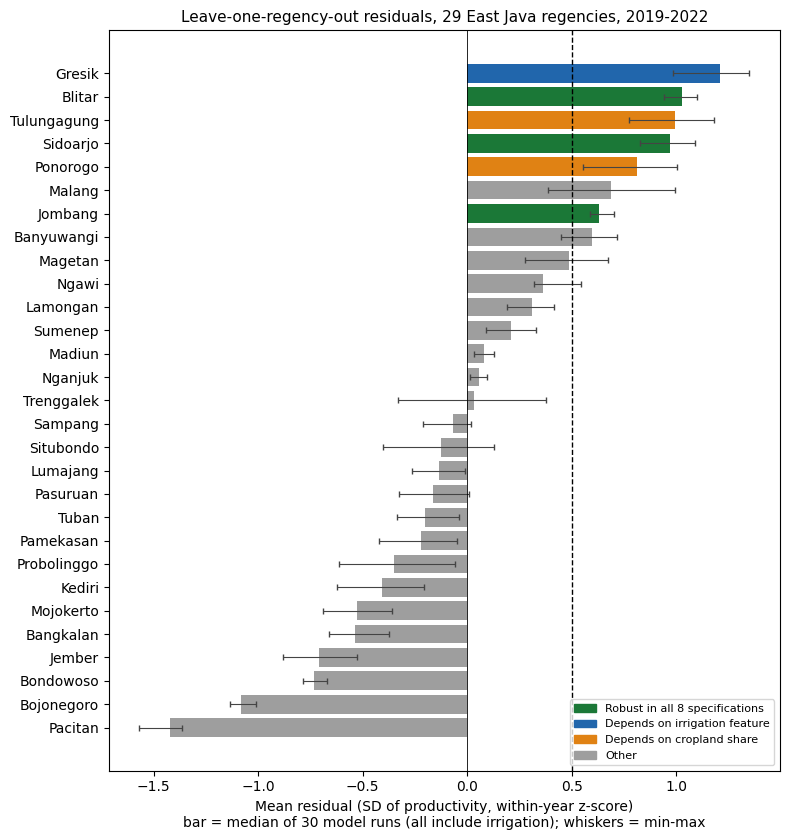

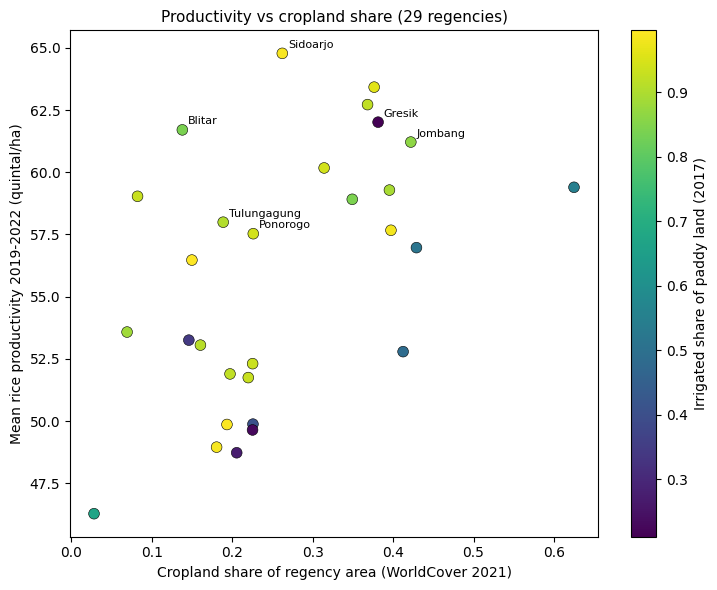

In [21]:
import os, matplotlib.pyplot as plt
from matplotlib.patches import Patch
os.makedirs('figures', exist_ok=True)

three = ['Sidoarjo', 'Jombang', 'Blitar']
irrig_dep = ['Gresik']
two = ['Tulungagung', 'Ponorogo']
labeled = three + irrig_dep + two

# Gambar 1: residual per kabupaten (median dan rentang 30 konfigurasi)
med = R.median(axis=1).sort_values()
lo, hi = R.min(axis=1)[med.index], R.max(axis=1)[med.index]
col = ['#1b7837' if n in three else
       ('#2166ac' if n in irrig_dep else
        ('#e08214' if n in two else '#9e9e9e')) for n in med.index]
fig, ax = plt.subplots(figsize=(8, 8.5))
ax.barh(med.index, med.values, color=col, xerr=[med - lo, hi - med],
        error_kw=dict(ecolor='#444', lw=0.8, capsize=2))
ax.axvline(0.5, ls='--', c='k', lw=1); ax.axvline(0, c='k', lw=0.6)
ax.set_xlabel('Mean residual (SD of productivity, within-year z-score)\n'
              'bar = median of 30 model runs (all include irrigation); whiskers = min-max')
ax.set_title('Leave-one-regency-out residuals, 29 East Java regencies, 2019-2022', fontsize=11)
ax.legend(handles=[Patch(color='#1b7837', label='Robust in all 8 specifications'),
                   Patch(color='#2166ac', label='Depends on irrigation feature'),
                   Patch(color='#e08214', label='Depends on cropland share'),
                   Patch(color='#9e9e9e', label='Other')], loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('figures/fig1_residuals_by_regency.png', dpi=200); plt.show()

# Gambar 2: produktivitas vs porsi cropland, warna = porsi irigasi
g = (df[df.jenis == 'kabupaten'].groupby('kabupaten_kota')
       .agg(prod=('y', 'mean'), crop=('crop_share', 'mean'), irig=('irig_share', 'first')))
fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(g.crop, g['prod'], c=g.irig, cmap='viridis', s=60, edgecolor='k', lw=0.4)
for n in labeled:
    ax.annotate(n, (g.loc[n, 'crop'], g.loc[n, 'prod']), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.colorbar(sc).set_label('Irrigated share of paddy land (2017)')
ax.set_xlabel('Cropland share of regency area (WorldCover 2021)')
ax.set_ylabel('Mean rice productivity 2019-2022 (quintal/ha)')
ax.set_title('Productivity vs cropland share (29 regencies)', fontsize=11)
plt.tight_layout(); plt.savefig('figures/fig2_productivity_vs_cropland.png', dpi=200); plt.show()